# Respiratory Variability Analysis in Patients Undergoing Radiotherapy Using ABC Spirometry Data

## Overview

This notebook performs respiratory variability analysis on free-breathing volume-time signals recorded using the Elekta Active Breathing Coordinator (ABC) system during radiotherapy treatment sessions.

The analysis evaluates:

* breath-to-breath respiratory cycle duration variability,
* tidal volume amplitude variability,
* intra-patient consistency across treatment fractions,
* and inter-patient variability across the study cohort.

The workflow includes:

* preprocessing of raw ABC `.dat` files,
* signal smoothing using Savitzky-Golay filtering,
* respiratory peak/trough detection,
* physiological cycle filtering,
* session-level variability metric extraction,
* statistical testing,
* and visualisation generation.

---

## Dataset

The dataset consists of anonymised respiratory recordings from six patients (`P1–P6`) undergoing ABC-guided radiotherapy.

Each recording contains:

* session time,
* lung volume,
* gating system states,
* and device control channels sampled at 50 Hz.

Only treatment-session recordings (`TRT`, `Tx`, `tx`, `sbrt`) are included in the final analysis.

---

## Primary Metrics

The following respiratory variability metrics are computed:

* Coefficient of variation of respiratory cycle duration (`CV_duration`)
* Coefficient of variation of tidal volume amplitude (`CV_amplitude`)
* Respiratory rate (`RR`)
* RMSSD of cycle duration
* Poincaré plot descriptors (`SD1`, `SD2`)

---

## Statistical Analysis

The notebook performs:

* Shapiro-Wilk normality testing,
* Levene equal-variance testing,
* Kruskal-Wallis inter-patient comparison,
* and post-hoc Mann-Whitney U analysis with Bonferroni correction.

This study is exploratory and intended as a pilot intra- and inter-patient variability analysis.

---

## Outputs

The notebook generates:

* descriptive statistics tables,
* intra-patient variability summaries,
* inter-patient comparison statistics,
* waveform visualisations,
* rolling respiratory timeseries,
* violin plots,
* breathing profile maps,
* and Poincaré plots.

---

## Reproducibility Note

All figures and statistical outputs are generated directly from the processed session data using the analysis pipeline implemented in this notebook. Patient identifiers have been anonymised for research documentation purposes.

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import kruskal

from private_patient_mapping import PATIENT_FILES
from private_patient_mapping import public_filename

import warnings
warnings.filterwarnings('ignore')

## Configuration and Signal Processing Parameters

In [2]:
BASE_PATH = '/path/to/your/data'

FS               = 50      # Sampling frequency (Hz)
MIN_CYCLE_SEC    = 2.0     # Minimum physiological breathing period
MAX_CYCLE_SEC    = 10.0    # Maximum physiological breathing period
MIN_AMPLITUDE_L  = 0.05    # Minimum respiratory amplitude threshold
MIN_CYCLES       = 5       # Minimum valid cycles per session

SMOOTH_WINDOW    = 51      # Savitzky-Golay smoothing window
SMOOTH_ORDER     = 3       # Savitzky-Golay polynomial order

PEAK_DISTANCE    = 100     # Minimum spacing between peaks
PEAK_PROMINENCE  = 0.05    # Minimum peak prominence

## Respiratory Signal Loading and Preprocessing

The following functions parse raw ABC respiratory recordings,
extract relevant respiratory channels, and preprocess the
waveforms prior to respiratory cycle detection.

Preprocessing includes:
- filtering for active ABC system intervals,
- conversion of respiratory channels to numeric format,
- removal of invalid samples,
- and chronological ordering of respiratory signals.

In [3]:
def read_dat_file(file_path: str) -> pd.DataFrame:
    """Load and parse ABC respiratory waveform file."""
    col_names = [
        "Session Time", "Volume (liters)", "Balloon Valve Status",
        "Patient Switch", "Gating Mode", "Gating Status", "Relay State"
    ]
    with open(file_path, 'r') as f:
        start_index = next(
            (i for i, line in enumerate(f) if "HeaderEnd" in line), 0
        ) + 1
    df = pd.read_csv(
        file_path, sep=r'\s*;\s*', skiprows=start_index,
        names=col_names, na_values=["-", " - ", "- "],
        engine="python", index_col=False
    )
    return df


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess respiratory waveform for cycle analysis."""
    # Retain intervals where the ABC system was active
    df = df[df['Patient Switch'] == 1].copy()
    
    df['Session Time']     = pd.to_numeric(df['Session Time'], errors='coerce')
    df['Volume (liters)']  = pd.to_numeric(df['Volume (liters)'], errors='coerce')
    df = df.dropna(subset=['Session Time', 'Volume (liters)'])
    df = df.sort_values('Session Time').reset_index(drop=True)
    
    return df

## Respiratory Cycle Detection

Respiratory cycles were identified using peak-to-trough-to-peak
analysis after Savitzky-Golay smoothing of the respiratory waveform.

Cycles were filtered using physiological duration and amplitude
constraints to exclude non-respiratory fluctuations and signal noise.

In [4]:
def detect_cycles(time: np.ndarray, volume: np.ndarray):
    """
    Detect respiratory peak-to-trough-to-peak cycles.
    Returns cycle durations, amplitudes, and rejected-cycle count.
    """

    if len(volume) < SMOOTH_WINDOW + 10:
        return [], [], 0

    # Apply smoothing prior to respiratory extrema detection
    v_smooth = savgol_filter(
        volume,
        window_length=SMOOTH_WINDOW,
        polyorder=SMOOTH_ORDER
    )

    # Detect inspiratory peaks
    peaks, _ = find_peaks(
        v_smooth,
        distance=PEAK_DISTANCE,
        prominence=PEAK_PROMINENCE
    )

    # Detect expiratory troughs
    troughs, _ = find_peaks(
        -v_smooth,
        distance=PEAK_DISTANCE,
        prominence=PEAK_PROMINENCE
    )

    if len(peaks) < 2:
        return [], [], 0

    durations = []
    amplitudes = []
    n_rejected = 0

    for i in range(len(peaks) - 1):

        p1 = peaks[i]
        p2 = peaks[i + 1]

        duration = time[p2] - time[p1]

        # Reject cycles outside physiological respiratory range
        if not (MIN_CYCLE_SEC <= duration <= MAX_CYCLE_SEC):
            n_rejected += 1
            continue

        between = [t for t in troughs if p1 < t < p2]

        if not between:
            n_rejected += 1
            continue

        trough_idx = min(between, key=lambda t: v_smooth[t])

        amplitude = v_smooth[p1] - v_smooth[trough_idx]

        # Reject low-amplitude respiratory events
        if amplitude < MIN_AMPLITUDE_L:
            n_rejected += 1
            continue

        durations.append(duration)
        amplitudes.append(amplitude)

    return durations, amplitudes, n_rejected

## Respiratory Variability Metrics

Session-level respiratory variability metrics were computed
from the detected respiratory cycles.

Primary variability measures included:
- coefficient of variation (CV),
- RMSSD,
- respiratory rate,
- and respiratory amplitude statistics.

In [5]:
def compute_metrics(durations: list, amplitudes: list) -> dict | None:
    """
    Compute respiratory variability metrics.
    """

    d = np.array(durations)
    a = np.array(amplitudes)

    if len(d) < 2:
        return None

    return {

        'n_cycles': len(d),

        'mean_duration': d.mean(),
        'std_duration': d.std(ddof=1),
        'cv_duration': d.std(ddof=1) / d.mean(),

        'rmssd_duration': np.sqrt(np.mean(np.diff(d) ** 2)),

        'mean_amplitude': a.mean(),
        'std_amplitude': a.std(ddof=1),
        'cv_amplitude': a.std(ddof=1) / a.mean(),

        'rmssd_amplitude': np.sqrt(np.mean(np.diff(a) ** 2)),

        'mean_rr_bpm': 60.0 / d.mean(),
    }

## Session-Level Respiratory Analysis

Each treatment session was independently analyzed to quantify
respiratory cycle variability and breathing pattern characteristics.

Sessions with insufficient waveform length or too few valid
respiratory cycles were excluded from downstream analysis.

In [6]:
def analyze_session(file_path: str, session_name: str) -> dict | None:
    """Run full pipeline on one session file."""
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None

    raw = read_dat_file(file_path)
    df  = preprocess(raw)

    if len(df) < 200:
        print(f"    [{session_name}] Too few rows ({len(df)}), skip")
        return None

    t, v = df['Session Time'].values, df['Volume (liters)'].values
    durations, amplitudes, n_rejected = detect_cycles(t, v)

    if len(durations) < MIN_CYCLES:
        print(f"    [{session_name}] Only {len(durations)} cycles, skip")
        return None

    print(
    f"    [{session_name}] "
    f"Valid cycles={len(durations)}, "
    f"Rejected cycles={n_rejected}"
    )

    m = compute_metrics(durations, amplitudes)
    if m is None:
        return None

    m.update({'session': session_name, 'file': public_filename(file_path),'raw_file': file_path,
               'durations': durations, 'amplitudes': amplitudes})
    return m

## Phase 1 — Intra-Patient Respiratory Variability Analysis

Respiratory variability metrics from individual treatment sessions
were aggregated at the patient level to evaluate pooled breathing
characteristics and intra-patient variability patterns.

In [7]:
def analyze_patient(session_files: dict, patient_name: str,
                    base_path: str = '') -> dict:
    """
    Phase 1: analyze one patient across all their sessions.
    Returns dict with session_df, patient_metrics, pooled arrays.
    """
    print(f"\n{'='*62}")
    print(f"  PATIENT: {patient_name}")
    print(f"{'='*62}")

    session_results = []
    all_durations, all_amplitudes = [], []

    for label, rel_path in session_files.items():
        full_path = os.path.join(base_path, rel_path) if base_path else rel_path
        res = analyze_session(full_path, label)
        if res:
            session_results.append(res)
            all_durations.extend(res['durations'])
            all_amplitudes.extend(res['amplitudes'])

    if not session_results:
        print(f"  ✗ No valid sessions for {patient_name}")
        return {}

    # Session-level table
    cols = ['session', 'n_cycles', 'mean_duration', 'cv_duration',
            'mean_amplitude', 'cv_amplitude', 'rmssd_duration',
            'rmssd_amplitude', 'mean_rr_bpm']
    session_df = pd.DataFrame([
        {k: r[k] for k in cols if k in r} for r in session_results
    ])

    print(f"\n  Session-wise Results:")
    print(session_df[['session','n_cycles','mean_duration','cv_duration',
                       'mean_amplitude','cv_amplitude','mean_rr_bpm'
                       ]].to_string(index=False, float_format='%.3f'))

    # Patient-level pooled metrics
    d_all = np.array(all_durations)
    a_all = np.array(all_amplitudes)

    pm = {
        'patient':                  patient_name,
        'n_sessions':               len(session_results),
        'total_cycles':             len(d_all),
        
        # --- PRIMARY METRICS (use these for inter-patient comparison) ---
        'pooled_cv_duration':       d_all.std(ddof=1) / d_all.mean(),
        'pooled_cv_amplitude':      a_all.std(ddof=1) / a_all.mean(),
        'pooled_mean_duration_sec': d_all.mean(),
        'pooled_mean_amplitude_L':  a_all.mean(),
        'pooled_mean_rr_bpm':       60.0 / d_all.mean(),
        'pooled_rmssd_duration':    np.sqrt(np.mean(np.diff(d_all)**2)),
        'pooled_rmssd_amplitude':   np.sqrt(np.mean(np.diff(a_all)**2)),
        
        # --- INTRA-PATIENT CONSISTENCY (meta-variability of session CVs) ---
        'avg_session_cv_duration':  session_df['cv_duration'].mean(),
        'avg_session_cv_amplitude': session_df['cv_amplitude'].mean(),
    }

    # Variability of session-level respiratory metrics
    if len(session_results) > 1:
        cv_d = session_df['cv_duration'].values
        cv_a = session_df['cv_amplitude'].values
        pm['cv_of_cv_duration']  = cv_d.std(ddof=1) / cv_d.mean() if cv_d.mean() > 0 else np.nan
        pm['cv_of_cv_amplitude'] = cv_a.std(ddof=1) / cv_a.mean() if cv_a.mean() > 0 else np.nan

        print(f"\n  Intra-Patient Variability Summary:")

        print(
            f"    Session CV_duration mean={cv_d.mean():.3f}, "
            f"SD={cv_d.std(ddof=1):.3f}"
        )

        print(
            f"    Session CV_amplitude mean={cv_a.mean():.3f}, "
            f"SD={cv_a.std(ddof=1):.3f}"
        )

        print(
            f"    CoV of session CV_duration="
            f"{pm['cv_of_cv_duration']:.3f}"
        )

        print(
            f"    CoV of session CV_amplitude="
            f"{pm['cv_of_cv_amplitude']:.3f}"
        )

    print(f"\n  Patient Summary: {patient_name}")
    print(f"    Sessions={pm['n_sessions']}, Total cycles={pm['total_cycles']}")
    print(f"    CV_duration={pm['pooled_cv_duration']:.3f}, "
          f"CV_amplitude={pm['pooled_cv_amplitude']:.3f}")
    print(f"    Mean RR={pm['pooled_mean_rr_bpm']:.1f} bpm, "
          f"Mean duration={pm['pooled_mean_duration_sec']:.2f} s")

    return {
        'patient_name':    patient_name,
        'session_results': session_results,
        'session_df':      session_df,
        'patient_metrics': pm,
        'all_durations':   d_all,
        'all_amplitudes':  a_all,
    }

## Phase 2 — Inter-Patient Respiratory Variability Comparison

Inter-patient respiratory variability differences were evaluated
using non-parametric statistical testing on session-level
respiratory variability metrics.

Kruskal-Wallis testing was performed to compare respiratory
variability distributions across the study cohort.

In [8]:
def compare_patients(all_results: list) -> pd.DataFrame:
    """
    Compare respiratory variability metrics across patients.
    """

    print("\n" + "=" * 62)
    print("INTER-PATIENT COMPARISON")
    print("=" * 62)

    if len(all_results) < 2:
        print("Insufficient number of patients for comparison.")
        return pd.DataFrame()

    rows = []

    for r in all_results:
        pm = r['patient_metrics']

        rows.append({
            'Patient':          pm['patient'],
            'Sessions':         pm['n_sessions'],
            'Total_Cycles':     pm['total_cycles'],
            'RR_bpm':           round(pm['pooled_mean_rr_bpm'], 1),
            'Mean_Duration_s':  round(pm['pooled_mean_duration_sec'], 2),
            'CV_Duration':      round(pm['pooled_cv_duration'], 3),
            'Mean_Amplitude_L': round(pm['pooled_mean_amplitude_L'], 3),
            'CV_Amplitude':     round(pm['pooled_cv_amplitude'], 3),
            'RMSSD_Duration':   round(pm['pooled_rmssd_duration'], 3),
            'RMSSD_Amplitude':  round(pm['pooled_rmssd_amplitude'], 3),
        })

    df = pd.DataFrame(rows)

    print("\nCross-Patient Summary Table:")
    print(df.to_string(index=False))

    # Session-level variability groups
    groups_dur = [
        r['session_df']['cv_duration'].values
        for r in all_results
    ]

    groups_amp = [
        r['session_df']['cv_amplitude'].values
        for r in all_results
    ]

    groups_dur = [g for g in groups_dur if len(g) >= 1]
    groups_amp = [g for g in groups_amp if len(g) >= 1]

    if len(groups_dur) >= 2:

        try:
            stat_d, p_d = kruskal(*groups_dur)
            stat_a, p_a = kruskal(*groups_amp)

            print("\nKruskal-Wallis Test Results:")
            print(f"CV_Duration : H={stat_d:.3f}, p={p_d:.4f}")
            print(f"CV_Amplitude: H={stat_a:.3f}, p={p_a:.4f}")

        except Exception as e:
            print(f"\nStatistical comparison could not be completed: {e}")

    return df

## Pipeline Execution

In [9]:
def run_all(base_path: str = BASE_PATH) -> tuple:
    """
    Run Phase 1 (intra-patient) for all patients, then Phase 2 (inter-patient).
    Returns: (all_results list, comparison DataFrame)
    """
    all_results = []

    for patient_name, sessions in PATIENT_FILES.items():
        # Build full paths
        full_sessions = {
            label: (os.path.join(base_path, rel) if base_path != '/path/to/your/data'
                    else rel)
            for label, rel in sessions.items()
        }
        result = analyze_patient(full_sessions, patient_name)
        if result:
            all_results.append(result)

    comparison_df = compare_patients(all_results)

    # Save results to CSV
    if not comparison_df.empty:
        out = 'breathing_results.csv'
        comparison_df.to_csv(out, index=False)
        print(f"\nResults saved to: {out}")

    return all_results, comparison_df

In [10]:
all_results, comparison_df = run_all()


  PATIENT: P1
    [TRT1] Valid cycles=357, Rejected cycles=26
    [TRT2] Valid cycles=316, Rejected cycles=24
    [TRT4] Valid cycles=224, Rejected cycles=26
    [TRT05] Valid cycles=228, Rejected cycles=20

  Session-wise Results:
session  n_cycles  mean_duration  cv_duration  mean_amplitude  cv_amplitude  mean_rr_bpm
   TRT1       357          3.118        0.183           0.565         0.146       19.246
   TRT2       316          3.484        0.194           0.218         0.463       17.223
   TRT4       224          3.317        0.282           0.221         0.515       18.087
  TRT05       228          3.001        0.147           0.230         0.508       19.991

  Intra-Patient Variability Summary:
    Session CV_duration mean=0.202, SD=0.057
    Session CV_amplitude mean=0.408, SD=0.176
    CoV of session CV_duration=0.284
    CoV of session CV_amplitude=0.432

  Patient Summary: P1
    Sessions=4, Total cycles=1125
    CV_duration=0.214, CV_amplitude=0.571
    Mean RR=18.5 bp

## Summary of Respiratory Variability Analysis

Respiratory variability metrics were successfully computed for all
included treatment-session recordings across the six-patient cohort.

Phase 1 intra-patient analysis demonstrated varying levels of
breathing consistency across treatment fractions, with differences
observed in respiratory cycle-duration variability and tidal-volume
amplitude variability between patients.

Phase 2 inter-patient comparison demonstrated statistically significant
differences in both `CV_duration` and `CV_amplitude`
(Kruskal-Wallis, p < 0.05), indicating heterogeneous respiratory
variability patterns across the study cohort.

The processed outputs generated in this stage were subsequently used
for statistical visualisation and exploratory respiratory variability
assessment.

# Respiratory Variability Visualisation Pipeline

The following section generates waveform visualisations, intra-patient
variability plots, inter-patient comparison plots, and nonlinear
respiratory variability representations derived from the processed
breathing-cycle metrics.

These visualisations are intended to:

- illustrate respiratory waveform characteristics,
- evaluate intra-patient breathing consistency,
- compare respiratory variability across patients,
- and support interpretation of the statistical analysis performed
  in the previous section.

All figures are generated directly from the processed respiratory
cycle data obtained from the analysis pipeline.

In [14]:
# This section uses the processed outputs generated from the
# respiratory variability analysis pipeline:
#
#     all_results, comparison_df = run_all(BASE_PATH)
#
# Statistical visualisations are generated directly from the
# previously computed respiratory cycle metrics.
#
# Raw waveform reloading is performed only for waveform display
# and does not recompute variability metrics.

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import kruskal, shapiro, levene, mannwhitneyu

import warnings
warnings.filterwarnings('ignore')

## Visualisation Configuration

The following configuration defines plotting styles,
figure-export settings, and patient-specific colour mapping
used throughout the visualisation pipeline.

In [16]:
OUTPUT_DIR = os.getcwd()
FIGURE_DPI = 150

COLOURS = {
    'P1':   '#2196F3',
    'P2':   '#E91E63',
    'P3':   '#FF9800',
    'P4':   '#4CAF50',
    'P5':   '#9C27B0',
    'P6':   '#F44336',
}

def _colour(patient_name):
    return COLOURS.get(patient_name, '#607D8B')

def _short(patient_name):
    return patient_name

def _style():
    plt.rcParams.update({
        'font.family':       'DejaVu Sans',
        'font.size':         11,
        'axes.titlesize':    13,
        'axes.labelsize':    11,
        'xtick.labelsize':   9,
        'ytick.labelsize':   9,
        'axes.spines.top':   False,
        'axes.spines.right': False,
    })

def _save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=FIGURE_DPI)
    print(f'  Saved -> {path}')
    plt.show()
    plt.close(fig)

def _p_marker(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

## Figure 1 — Respiratory Waveform and Breathing Cycle Detection

This figure visualises the respiratory waveform following preprocessing and Savitzky-Golay smoothing.

Detected inspiratory peaks and expiratory troughs are overlaid on the waveform to demonstrate the respiratory cycle detection methodology used throughout the study.

The lower panel visualises respiratory cycle durations identified within the selected waveform segment and highlights cycles retained after physiological filtering.

In [17]:
# Figure 1 HELPER — RAW WAVEFORM LOADING
def _load_raw_session(session_result):
    """
    Load preprocessed respiratory waveform for Figure 1 visualisation.

    This helper reloads the original session file using the stored
    session path generated during the approved analysis pipeline.

    The function is used only for waveform display and does not
    recompute respiratory variability metrics.
    """

    file_path = session_result['raw_file']

    raw = read_dat_file(file_path)
    df = preprocess(raw)

    t = df['Session Time'].values
    v = df['Volume (liters)'].values

    # Savitzky-Golay smoothing for respiratory waveform visualisation
    vs = savgol_filter(v, SMOOTH_WINDOW, SMOOTH_ORDER)

    return t, v, vs

In [18]:
# Figure 1 — WAVEFORM + DETECTED PEAKS/TROUGHS
def fig1_waveform(all_results):
    print('\nGenerating Figure 1 — Respiratory waveform and cycle detection...')
    _style()

    r = all_results[0]
    pname = r['patient_name']
    sess = r['session_results'][0]
    session = sess['session']
    colour = _colour(pname)

    t, v, vs = _load_raw_session(sess)

    t_mid = (t[0] + t[-1]) / 2
    mask = (t >= t_mid) & (t <= t_mid + 90)

    tw, vw, vsw = t[mask], v[mask], vs[mask]
    tw0 = tw - tw[0]

    peaks, _ = find_peaks(vsw, distance=PEAK_DISTANCE, prominence=PEAK_PROMINENCE)
    troughs, _ = find_peaks(-vsw, distance=PEAK_DISTANCE, prominence=PEAK_PROMINENCE)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(13, 6), sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08}
    )

    ax_top.plot(tw0, vw, color='#BDBDBD', lw=0.8, label='Raw respiratory waveform', zorder=1)
    ax_top.plot(tw0, vsw, color=colour, lw=1.8, label='Smoothed waveform', zorder=2)
    ax_top.scatter(tw0[peaks], vsw[peaks], color='#1565C0', s=55, zorder=3,
                   label=f'Inspiratory peaks (n={len(peaks)})')
    ax_top.scatter(tw0[troughs], vsw[troughs], color='#B71C1C', s=55,
                   marker='v', zorder=3, label=f'Expiratory troughs (n={len(troughs)})')
    ax_top.axhline(0, color='k', lw=0.5, ls='--', alpha=0.35)
    ax_top.set_ylabel('Volume (litres)')
    ax_top.set_title(
        'Respiratory Waveform and Breathing Cycle Detection\n'
        f'{pname} · {session} · 90-second analysis window',
        fontweight='bold'
    )
    ax_top.legend(loc='upper right', fontsize=9, framealpha=0.75)

    if len(peaks) > 1:
        peak_t = tw0[peaks]
        d_plot = np.diff(peak_t)
        mids = (peak_t[:-1] + peak_t[1:]) / 2
        valid = (d_plot >= MIN_CYCLE_SEC) & (d_plot <= MAX_CYCLE_SEC)

        ax_bot.bar(mids[valid], d_plot[valid], width=0.35,
                   color=colour, alpha=0.75, label='Valid cycle')
        ax_bot.bar(mids[~valid], d_plot[~valid], width=0.35,
                   color='#9E9E9E', alpha=0.55, label='Outside duration range')

        if valid.any():
            ax_bot.axhline(d_plot[valid].mean(), color='k', lw=1.2, ls='--',
                           alpha=0.6, label=f'Mean {d_plot[valid].mean():.2f} s')

    ax_bot.set_ylabel('Respiratory Cycle Duration (s)')
    ax_bot.set_xlabel('Time Within Selected Window (s)')
    ax_bot.set_ylim(0, MAX_CYCLE_SEC + 2)
    ax_bot.legend(loc='upper right', fontsize=8, framealpha=0.75)

    plt.tight_layout()
    _save(fig, 'fig1_waveform_cycles.png')

## Figure 2 — Respiratory Cycle Duration Timeseries

This figure visualises temporal variation in respiratory cycle duration across sequential breaths within treatment sessions.

Rolling-average trends are displayed to evaluate short-term respiratory rhythm variability and intra-session breathing stability during ABC-guided radiotherapy.

In [19]:
def fig2_duration_timeseries(all_results):
    print('\nGenerating Figure 2 — Respiratory cycle duration timeseries...')
    _style()

    n = len(all_results)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(14, 3.2 * n),
        sharex=False,
        gridspec_kw={'hspace': 0.55}
    )

    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, all_results):
        pname = r['patient_name']
        colour = _colour(pname)
        sessions = r['session_results']

        for idx, sess in enumerate(sessions):
            durs = np.array(sess['durations'])
            x = np.arange(1, len(durs) + 1)

            roll = pd.Series(durs).rolling(5, center=True).mean().values

            alpha = 0.30 + 0.45 * (idx + 1) / len(sessions)

            ax.plot(
                x, roll,
                lw=1.8,
                alpha=alpha,
                label=f'{sess["session"]} (n={len(durs)})'
            )

        pooled_mean = r['patient_metrics']['pooled_mean_duration_sec']

        ax.axhline(
            pooled_mean,
            color='k',
            lw=1.1,
            ls='--',
            alpha=0.65,
            label=f'Pooled mean = {pooled_mean:.2f}s'
        )

        ax.set_ylim(0, MAX_CYCLE_SEC + 1)
        ax.set_ylabel('Respiratory Cycle Duration (s)')
        ax.set_title(
            f'{pname} — all treatment sessions',
            fontsize=11,
            fontweight='bold',
            color=colour
        )
        ax.legend(fontsize=7, framealpha=0.65, ncol=3)

    axes[-1].set_xlabel('Breath number within session')

    fig.suptitle(
        'Breath-to-Breath Respiratory Cycle Duration Variability Across Treatment Sessions\n'
        '(5-cycle rolling mean shown for each treatment session)',
        fontsize=13,
        fontweight='bold',
        y=1.01
    )

    plt.tight_layout()
    _save(fig, 'fig2_all_sessions_duration_timeseries.png')

## Figure 3 — Intra-Patient Variability of Respiratory Cycle Duration

Session-level respiratory cycle duration variability (`CV_duration`) is visualised for each patient to assess intra-patient respiratory rhythm consistency across treatment fractions.

Mean intra-patient variability and session-wise spread are displayed to evaluate respiratory cycle regularity during ABC-guided radiotherapy treatment sessions.

In [20]:
def fig3_intra_cv_duration(all_results):
    print('\nGenerating Figure 3 — Intra-patient respiratory cycle duration variability...')
    _style()

    n = len(all_results)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, all_results):
        pname = r['patient_name']
        colour = _colour(pname)
        df = r['session_df']

        sess = df['session'].tolist()
        cvs = df['cv_duration'].values
        mn = cvs.mean()
        sd = cvs.std(ddof=1) if len(cvs) > 1 else 0.0

        bars = ax.bar(range(len(sess)), cvs, color=colour, alpha=0.78,
                      edgecolor='white', linewidth=0.6, zorder=2)
        ax.axhline(mn, color='k', lw=1.6, ls='--', alpha=0.7,
                   label=f'Mean = {mn:.3f}', zorder=3)
        ax.axhspan(mn - sd, mn + sd, alpha=0.09, color=colour, zorder=1,
                   label=f'SD = {sd:.3f}')

        for bar, cv in zip(bars, cvs):
            ax.text(bar.get_x() + bar.get_width() / 2, cv + 0.004,
                    f'{cv:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(range(len(sess)))
        ax.set_xticklabels(sess, rotation=35, ha='right', fontsize=8)
        ax.set_ylim(0, max(cvs) * 1.50)
        ax.set_ylabel('CV of Respiratory Cycle Duration')
        ax.set_title(pname, fontsize=11, fontweight='bold', color=colour)
        ax.legend(fontsize=8, framealpha=0.65)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(
        'Intra-Patient Variability of Respiratory Cycle Duration',
        fontsize=13, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    _save(fig, 'fig3_intra_cv_duration.png')

## Figure 4 — Intra-Patient Variability of Tidal Volume Amplitude

This figure visualises session-level respiratory amplitude variability within individual patients using per-session coefficient of variation of tidal volume amplitude (`CV_amplitude`) measurements across treatment fractions.

Mean intra-patient variability and session-wise spread are displayed to evaluate respiratory amplitude consistency during ABC-guided radiotherapy treatment sessions.

In [21]:
def fig4_intra_cv_amplitude(all_results):
    print('\nGenerating Figure 4 — Intra-patient tidal volume amplitude variability...')
    _style()

    n = len(all_results)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, all_results):
        pname = r['patient_name']
        colour = _colour(pname)
        df = r['session_df']

        sess = df['session'].tolist()
        cvs = df['cv_amplitude'].values
        mn = cvs.mean()
        sd = cvs.std(ddof=1) if len(cvs) > 1 else 0.0

        bars = ax.bar(range(len(sess)), cvs, color=colour, alpha=0.78,
                      edgecolor='white', linewidth=0.6, zorder=2)
        ax.axhline(mn, color='k', lw=1.6, ls='--', alpha=0.7,
                   label=f'Mean = {mn:.3f}', zorder=3)
        ax.axhspan(mn - sd, mn + sd, alpha=0.09, color=colour, zorder=1,
                   label=f'SD = {sd:.3f}')

        for bar, cv in zip(bars, cvs):
            ax.text(bar.get_x() + bar.get_width() / 2, cv + 0.006,
                    f'{cv:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(range(len(sess)))
        ax.set_xticklabels(sess, rotation=35, ha='right', fontsize=8)
        ax.set_ylim(0, max(cvs) * 1.50)
        ax.set_ylabel('CV of Tidal Volume Amplitude')
        ax.set_title(pname, fontsize=11, fontweight='bold', color=colour)
        ax.legend(fontsize=8, framealpha=0.65)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(
        'Intra-Patient Variability of Tidal Volume Amplitude',
        fontsize=13, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    _save(fig, 'fig4_intra_cv_amplitude.png')

## Figure 5 — Inter-Patient Variability of Respiratory Cycle Duration

Violin distributions of per-session `CV_duration` values are used to compare respiratory rhythm variability across patients.

Session-level observations, interquartile ranges, and pooled patient means are visualised simultaneously to assess inter-patient respiratory variability patterns.

Kruskal-Wallis statistical testing is incorporated directly into the figure.

In [22]:
def fig5_inter_cv_duration(all_results):

    print('\nGenerating Figure 5: Inter-patient CV_duration comparison')

    _style()

    fig, ax = plt.subplots(
        figsize=(max(10, 2 * len(all_results)), 6)
    )

    pos = np.arange(len(all_results))
    groups = []

    rng = np.random.RandomState(42)

    for i, r in enumerate(all_results):

        pname = r['patient_name']
        colour = _colour(pname)

        cvs = r['session_df']['cv_duration'].values
        groups.append(cvs)

        # Violin distribution
        parts = ax.violinplot(
            cvs,
            positions=[i],
            widths=0.65,
            showmeans=False,
            showextrema=False
        )

        for pc in parts['bodies']:
            pc.set_facecolor(colour)
            pc.set_alpha(0.30)

        # Interquartile range + median
        q1, med, q3 = np.percentile(cvs, [25, 50, 75])

        ax.plot(
            [i - 0.13, i + 0.13],
            [med, med],
            color=colour,
            lw=2.5,
            zorder=4
        )

        ax.add_patch(
            mpatches.FancyBboxPatch(
                (i - 0.15, q1),
                0.30,
                q3 - q1,
                boxstyle='round,pad=0.01',
                facecolor='none',
                edgecolor=colour,
                lw=2.0,
                zorder=3
            )
        )

        # Session-level points
        jitter = (rng.rand(len(cvs)) - 0.5) * 0.20

        ax.scatter(
            pos[i] + jitter,
            cvs,
            color=colour,
            s=75,
            zorder=5,
            edgecolors='white',
            lw=0.8
        )

        # Pooled patient mean
        ax.scatter(
            i,
            cvs.mean(),
            color='k',
            s=100,
            marker='D',
            zorder=6,
            edgecolors='white',
            lw=0.8
        )

    # Kruskal-Wallis test
    H, p_val = kruskal(*groups)

    ax.text(
        0.98,
        0.97,
        f'Kruskal-Wallis\nH = {H:.2f}, p = {p_val:.4f} {_p_marker(p_val)}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            fc='white',
            alpha=0.85,
            ec='#BDBDBD'
        )
    )

    ax.set_xticks(pos)

    ax.set_xticklabels(
        [_short(r['patient_name']) for r in all_results],
        fontsize=11
    )

    ax.set_ylabel('CV of Respiratory Cycle Duration')
    ax.set_xlabel('Patient')

    ax.set_title(
        'Inter-Patient Respiratory Rhythm Variability',
        fontsize=13,
        fontweight='bold'
    )

    handles = [
        mpatches.Patch(
            color=_colour(r['patient_name']),
            label=r['patient_name']
        )
        for r in all_results
    ]

    ax.legend(
        handles=handles,
        fontsize=8.5,
        framealpha=0.75,
        ncol=2,
        loc='upper left'
    )

    plt.tight_layout()

    _save(fig, 'fig5_inter_cv_duration.png')

## Figure 6 — Inter-Patient Comparison of Tidal Volume Amplitude Variability

This figure visualises the distribution of per-session tidal volume amplitude variability (`CV_amplitude`) across the patient cohort.

Violin distributions, interquartile ranges, pooled patient means, and individual session-level observations are displayed to evaluate inter-patient differences in respiratory amplitude variability during ABC-guided radiotherapy.

Kruskal-Wallis statistical testing is incorporated directly into the visualisation to assess statistical significance across patients.

In [23]:
def fig6_inter_cv_amplitude(all_results):
    print('\nGenerating Figure 6 — Inter-patient tidal volume amplitude variability...')
    _style()

    fig, ax = plt.subplots(figsize=(max(10, 2 * len(all_results)), 6))
    pos = np.arange(len(all_results))
    groups = []

    rng = np.random.RandomState(42)

    for i, r in enumerate(all_results):
        pname = r['patient_name']
        colour = _colour(pname)
        cvs = r['session_df']['cv_amplitude'].values
        groups.append(cvs)

        parts = ax.violinplot(cvs, positions=[i], widths=0.65,
                              showmeans=False, showextrema=False)

        for pc in parts['bodies']:
            pc.set_facecolor(colour)
            pc.set_alpha(0.30)

        q1, med, q3 = np.percentile(cvs, [25, 50, 75])
        ax.plot([i - 0.13, i + 0.13], [med, med], color=colour, lw=2.5, zorder=4)
        ax.add_patch(mpatches.FancyBboxPatch(
            (i - 0.15, q1), 0.30, q3 - q1,
            boxstyle='round,pad=0.01',
            facecolor='none',
            edgecolor=colour,
            lw=2.0,
            zorder=3
        ))

        jitter = (rng.rand(len(cvs)) - 0.5) * 0.20
        ax.scatter(pos[i] + jitter, cvs, color=colour, s=75, zorder=5,
                   edgecolors='white', lw=0.8)
        ax.scatter(i, cvs.mean(), color='k', s=100, marker='D', zorder=6,
                   edgecolors='white', lw=0.8)

    H, p_val = kruskal(*groups)
    ax.text(
        0.98, 0.97,
        f'Kruskal-Wallis Test\nH = {H:.2f}, p = {p_val:.4f} {_p_marker(p_val)}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85, ec='#BDBDBD')
    )

    ax.set_xticks(pos)
    ax.set_xticklabels([_short(r['patient_name']) for r in all_results], fontsize=11)
    ax.set_ylabel('CV of Tidal Volume Amplitude')
    ax.set_xlabel('Patient')
    ax.set_title(
        'Inter-Patient Comparison of Tidal Volume Amplitude Variability\n'
        '(Diamond = pooled patient mean, box = IQR, dots = treatment sessions)',
        fontsize=13,
        fontweight='bold'
    )

    handles = [mpatches.Patch(color=_colour(r['patient_name']), label=r['patient_name'])
               for r in all_results]
    ax.legend(handles=handles, fontsize=8.5, framealpha=0.75, ncol=2, loc='upper right')

    plt.tight_layout()
    _save(fig, 'fig6_inter_cv_amplitude.png')

## Figure 7 — Inter-Patient Respiratory Variability Profile

A two-dimensional respiratory variability map is generated using pooled patient-level variability metrics.

Each large marker represents the pooled respiratory variability of an individual patient based on all valid respiratory cycles across treatment sessions.

Smaller semi-transparent points represent individual treatment-session observations.

Horizontal and vertical error bars indicate intra-patient variability across sessions for respiratory cycle duration and tidal volume amplitude variability.

In [24]:
def fig7_scatter_profile(all_results):

    print('\nGenerating Figure 7: Inter-patient respiratory variability profile')

    _style()

    fig, ax = plt.subplots(figsize=(9, 7.5))

    # Aggregate session-level variability values
    all_cv_d = np.concatenate([
        r['session_df']['cv_duration'].values
        for r in all_results
    ])

    all_cv_a = np.concatenate([
        r['session_df']['cv_amplitude'].values
        for r in all_results
    ])

    # Population medians
    med_d = np.median(all_cv_d)
    med_a = np.median(all_cv_a)

    # Population centres
    cx = all_cv_d.mean()
    cy = all_cv_a.mean()

    for r in all_results:

        pname = r['patient_name']
        colour = _colour(pname)
        pm = r['patient_metrics']

        # Session-level variability
        cv_d_sess = r['session_df']['cv_duration'].values
        cv_a_sess = r['session_df']['cv_amplitude'].values

        # Pooled patient-level metrics
        mn_d = pm['pooled_cv_duration']
        mn_a = pm['pooled_cv_amplitude']

        # Intra-patient spread
        sd_d = cv_d_sess.std(ddof=1) if len(cv_d_sess) > 1 else 0.0
        sd_a = cv_a_sess.std(ddof=1) if len(cv_a_sess) > 1 else 0.0

        # Session-level points
        ax.scatter(
            cv_d_sess,
            cv_a_sess,
            color=colour,
            s=50,
            alpha=0.30,
            edgecolors='none',
            zorder=2
        )

        # Pooled patient marker with variability bars
        ax.errorbar(
            mn_d,
            mn_a,
            xerr=sd_d,
            yerr=sd_a,
            fmt='o',
            color=colour,
            ms=14,
            lw=1.8,
            capsize=5,
            capthick=1.5,
            zorder=4,
            label=pname,
            markeredgecolor='white',
            markeredgewidth=1.2
        )

        # Label placement
        ox = 6 if mn_d >= cx else -6
        oy = 6 if mn_a >= cy else -14

        ax.annotate(
            _short(pname),
            xy=(mn_d, mn_a),
            xytext=(ox, oy),
            textcoords='offset points',
            fontsize=9.5,
            color=colour,
            fontweight='bold',
            ha='left' if ox > 0 else 'right'
        )

    # Population reference lines
    ax.axvline(
        med_d,
        color='#9E9E9E',
        lw=1.0,
        ls='--',
        alpha=0.55,
        zorder=1
    )

    ax.axhline(
        med_a,
        color='#9E9E9E',
        lw=1.0,
        ls='--',
        alpha=0.55,
        zorder=1
    )

    ax.set_xlabel('CV of Respiratory Cycle Duration')
    ax.set_ylabel('CV of Tidal Volume Amplitude')

    ax.set_title(
        'Inter-Patient Respiratory Variability Profile',
        fontsize=13,
        fontweight='bold'
    )

    ax.legend(
        fontsize=9,
        framealpha=0.75,
        loc='center right'
    )

    plt.tight_layout()

    _save(fig, 'fig7_respiratory_variability_profile.png')

## Figure 8 — Poincaré Analysis of Respiratory Cycle Regularity

Poincaré plots of successive respiratory cycle durations (`RR(n)` versus `RR(n+1)`) are used to evaluate short-term and long-term respiratory rhythm variability across patients.

Each subplot represents the first analysed treatment session for an individual patient. The fitted ellipse visualises the dispersion of respiratory cycle intervals, while the derived SD1 and SD2 descriptors quantify short-term and long-term breathing variability, respectively.

This analysis provides an additional nonlinear assessment of respiratory regularity under ABC-guided radiotherapy conditions.

In [25]:
def fig8_poincare(all_results):
    print('\nGenerating Figure 8 — Poincaré respiratory variability plots...')
    _style()

    n = len(all_results)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.5 * nrows),
                             gridspec_kw={'hspace': 0.40, 'wspace': 0.35})
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, all_results):
        pname = r['patient_name']
        colour = _colour(pname)
        sess = r['session_results'][0]
        durs = np.array(sess['durations'])
        session = sess['session']

        if len(durs) < 4:
            ax.text(0.5, 0.5, 'Too few cycles',
                    ha='center', va='center', transform=ax.transAxes, color='grey')
            continue

        rr_n = durs[:-1]
        rr_n1 = durs[1:]

        sd1 = np.sqrt(np.var(rr_n1 - rr_n, ddof=1) / 2)
        sd2 = np.sqrt(np.var(rr_n1 + rr_n, ddof=1) / 2)

        ax.scatter(rr_n, rr_n1, color=colour, s=12, alpha=0.40,
                   edgecolors='none', zorder=2)

        lim = [
            min(rr_n.min(), rr_n1.min()) - 0.2,
            max(rr_n.max(), rr_n1.max()) + 0.2
        ]

        ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.45, zorder=1)

        ellipse = Ellipse(
            xy=(rr_n.mean(), rr_n1.mean()),
            width=2 * sd2 * np.sqrt(2),
            height=2 * sd1 * np.sqrt(2),
            angle=45,
            edgecolor=colour,
            facecolor='none',
            lw=2.2,
            zorder=3
        )
        ax.add_patch(ellipse)

        ax.text(
            0.04, 0.96,
            f'SD1 = {sd1:.3f} s\n'
            f'SD2 = {sd2:.3f} s\n'
            f'n = {len(durs)} cycles · {session}',
            transform=ax.transAxes,
            fontsize=8,
            va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.78)
        )

        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xlabel('Respiratory Cycle Duration RR(n) (s)', fontsize=9)
        ax.set_ylabel('Respiratory Cycle Duration RR(n+1) (s)', fontsize=9)
        ax.set_title(pname, fontsize=11, fontweight='bold', color=colour)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(
        'Poincaré Plot — Respiratory Cycle Regularity',
        fontsize=12,
        fontweight='bold',
        y=1.01
    )

    _save(fig, 'fig8_poincare.png')


# =============================================================================
# STATISTICS TABLES
# =============================================================================

def print_statistics(all_results):
    sep = '=' * 72
    pnames = [r['patient_name'] for r in all_results]

    print(f'\n{sep}\nTable 1 — Descriptive Statistics per Patient\n{sep}')
    print(f'{"Patient":<22} {"Sessions":>8} {"Cycles":>7} {"RR(bpm)":>8} '
          f'{"Dur_mean":>9} {"CV_dur":>7} {"Amp_mean":>9} {"CV_amp":>7}')
    print('-' * 76)

    for r in all_results:
        pm = r['patient_metrics']
        print(f'{pm["patient"]:<22} {pm["n_sessions"]:>8} '
              f'{pm["total_cycles"]:>7} {pm["pooled_mean_rr_bpm"]:>8.1f} '
              f'{pm["pooled_mean_duration_sec"]:>9.3f} '
              f'{pm["pooled_cv_duration"]:>7.3f} '
              f'{pm["pooled_mean_amplitude_L"]:>9.3f} '
              f'{pm["pooled_cv_amplitude"]:>7.3f}')

    print(f'\n{sep}\nTable 2 — Intra-Patient Consistency\n{sep}')
    print(f'{"Patient":<22} {"CVd_spread":>11} {"CoV_CVd":>9} '
          f'{"CVa_spread":>11} {"CoV_CVa":>9} {"Stable?":>9}')
    print('-' * 76)

    for r in all_results:
        pm = r['patient_metrics']
        df = r['session_df']

        cvd = df['cv_duration'].values
        cva = df['cv_amplitude'].values

        coc_d = pm.get('cv_of_cv_duration', np.nan)
        coc_a = pm.get('cv_of_cv_amplitude', np.nan)

        stable = 'YES' if pd.notna(coc_d) and coc_d < 0.30 else 'NO'

        print(f'{pm["patient"]:<22} '
              f'{cvd.std(ddof=1) if len(cvd)>1 else 0:>11.3f} {coc_d:>9.3f} '
              f'{cva.std(ddof=1) if len(cva)>1 else 0:>11.3f} {coc_a:>9.3f} '
              f'{stable:>9}')

    print(f'\n{sep}\nTable 3 — Shapiro-Wilk Normality on per-session CV_duration\n{sep}')
    print(f'{"Patient":<22} {"W":>8} {"p-value":>10} {"Normal?":>9}')
    print('-' * 52)

    for r in all_results:
        cvs = r['session_df']['cv_duration'].values

        if len(cvs) >= 3:
            w, pv = shapiro(cvs)
            print(f'{r["patient_name"]:<22} {w:>8.4f} {pv:>10.4f} '
                  f'{"Yes" if pv > 0.05 else "No":>9}')
        else:
            print(f'{r["patient_name"]:<22} {"n<3":>8} {"NA":>10} {"NA":>9}')

    gd = [r['session_df']['cv_duration'].values for r in all_results]
    ga = [r['session_df']['cv_amplitude'].values for r in all_results]

    print(f'\n{sep}\nTable 4 — Levene Equal-Variance Test\n{sep}')
    ld = levene(*gd)
    la = levene(*ga)

    print(f'  CV_Duration:  F={ld.statistic:.3f}, p={ld.pvalue:.4f}')
    print(f'  CV_Amplitude: F={la.statistic:.3f}, p={la.pvalue:.4f}')

    print(f'\n{sep}\nTable 5 — Kruskal-Wallis Test\n{sep}')
    Hd, pd_kw = kruskal(*gd)
    Ha, pa_kw = kruskal(*ga)

    print(f'  CV_Duration:  H={Hd:.3f}, p={pd_kw:.4f} {_p_marker(pd_kw)}')
    print(f'  CV_Amplitude: H={Ha:.3f}, p={pa_kw:.4f} {_p_marker(pa_kw)}')

    n_pairs = len(pnames) * (len(pnames) - 1) // 2
    alpha_corr = 0.05 / n_pairs if n_pairs > 0 else 0.05

    print(f'\n{sep}\nTable 6 — Post-Hoc Mann-Whitney U on CV_duration\nBonferroni alpha = {alpha_corr:.4f}\n{sep}')
    print(f'{"Pair":<38} {"U":>8} {"p_raw":>10} {"p_adj":>10} {"Sig?":>5}')
    print('-' * 74)

    for i, r1 in enumerate(all_results):
        for j, r2 in enumerate(all_results):
            if j <= i:
                continue

            g1 = r1['session_df']['cv_duration'].values
            g2 = r2['session_df']['cv_duration'].values

            U, p_raw = mannwhitneyu(g1, g2, alternative='two-sided')
            p_adj = min(p_raw * n_pairs, 1.0)

            pair = f'{_short(r1["patient_name"])} vs {_short(r2["patient_name"])}'

            print(f'{pair:<38} {U:>8.1f} {p_raw:>10.4f} {p_adj:>10.4f} '
                  f'{"YES" if p_adj < 0.05 else "":>5}')

    print(f'\n{sep}\nTable 7 — Poincare Metrics, first session per patient\n{sep}')
    print(f'{"Patient":<22} {"Session":>8} {"SD1(s)":>9} {"SD2(s)":>9} '
          f'{"SD1/SD2":>9} {"n_cycles":>9}')
    print('-' * 70)

    for r in all_results:
        sess = r['session_results'][0]
        d = np.array(sess['durations'])

        if len(d) >= 4:
            sd1 = np.sqrt(np.var(d[1:] - d[:-1], ddof=1) / 2)
            sd2 = np.sqrt(np.var(d[1:] + d[:-1], ddof=1) / 2)

            print(f'{r["patient_name"]:<22} {sess["session"]:>8} '
                  f'{sd1:>9.4f} {sd2:>9.4f} {sd1/sd2:>9.4f} {len(d):>9}')

    cv_d_all = [r['patient_metrics']['pooled_cv_duration'] for r in all_results]
    cv_a_all = [r['patient_metrics']['pooled_cv_amplitude'] for r in all_results]

    p_best = pnames[int(np.argmin(cv_d_all))]
    p_worst = pnames[int(np.argmax(cv_d_all))]

    stable = [
        r['patient_name']
        for r in all_results
        if r['patient_metrics'].get('cv_of_cv_duration', 1.0) < 0.30
    ]

    print(f'\n{sep}\nKEY FINDINGS\n{sep}')
    print(f'  Intra-patient stability: {len(stable)} of {len(pnames)} patients below CoV-of-CV 0.30')
    print(f'  Kruskal-Wallis CV_duration p={pd_kw:.4f}')
    print(f'  Kruskal-Wallis CV_amplitude p={pa_kw:.4f}')
    print(f'  CV_duration range: {min(cv_d_all):.3f} ({_short(p_best)}) '
          f'to {max(cv_d_all):.3f} ({_short(p_worst)})')
    print(f'  CV_amplitude range: {min(cv_a_all):.3f} to {max(cv_a_all):.3f}')

## Visualisation and Statistical Analysis Execution

The following runner function generates all respiratory variability visualisations and statistical summary tables using the previously computed analysis results.

All outputs are exported directly to the working directory for inclusion in the research manuscript and supplementary analysis documentation.

RESPIRATORY VARIABILITY — VISUALISATION AND STATISTICAL ANALYSIS
Using existing outputs from the approved analysis pipeline

Generating Figure 1 — Respiratory waveform and cycle detection...
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig1_waveform_cycles.png


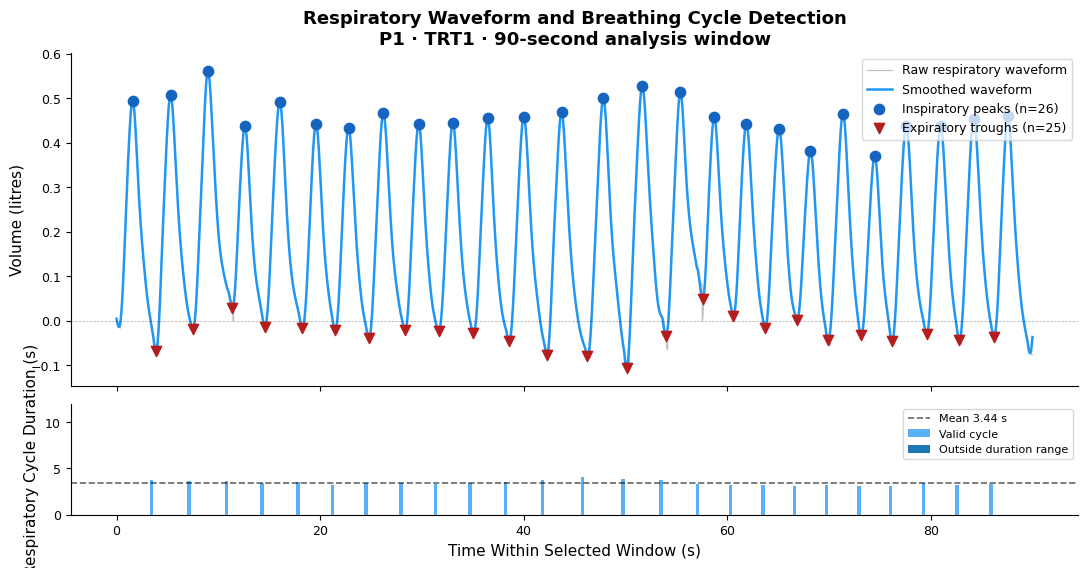


Generating Figure 2 — Respiratory cycle duration timeseries...
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig2_all_sessions_duration_timeseries.png


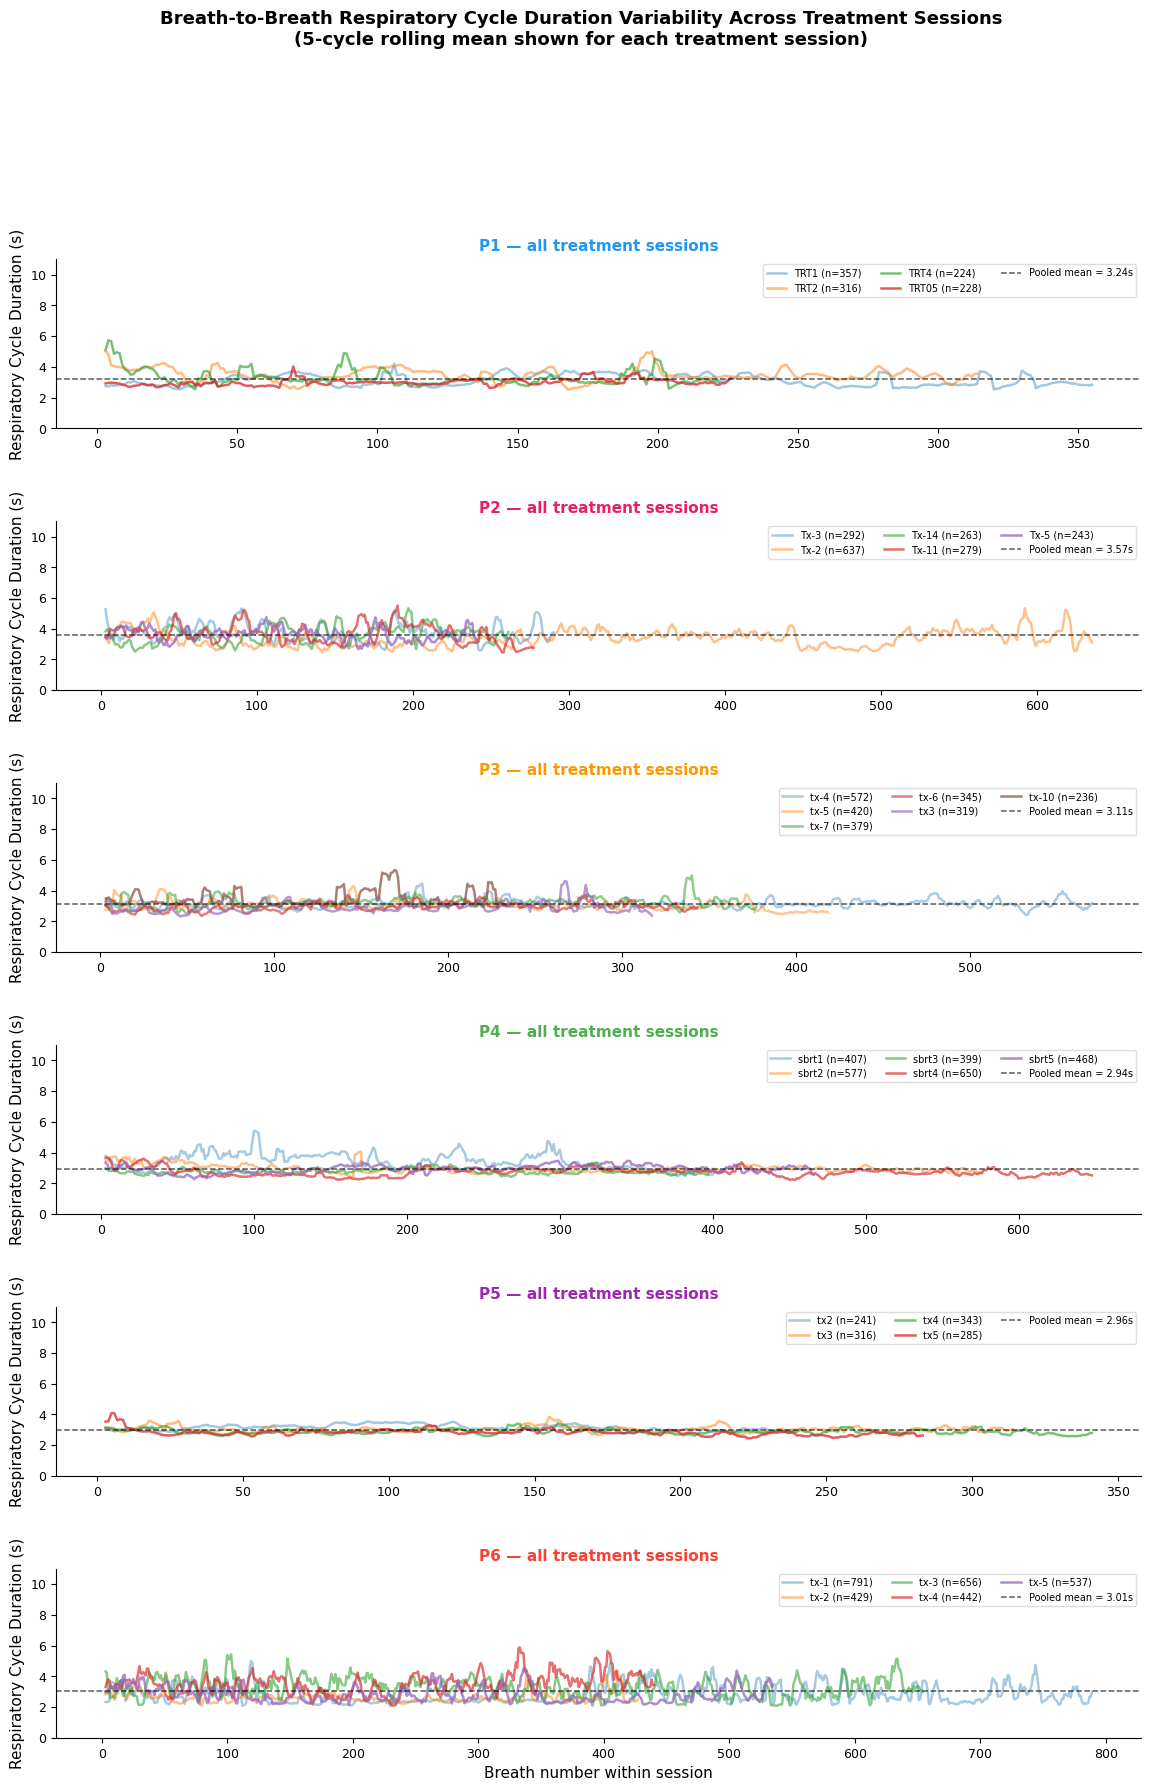


Generating Figure 3 — Intra-patient respiratory cycle duration variability...
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig3_intra_cv_duration.png


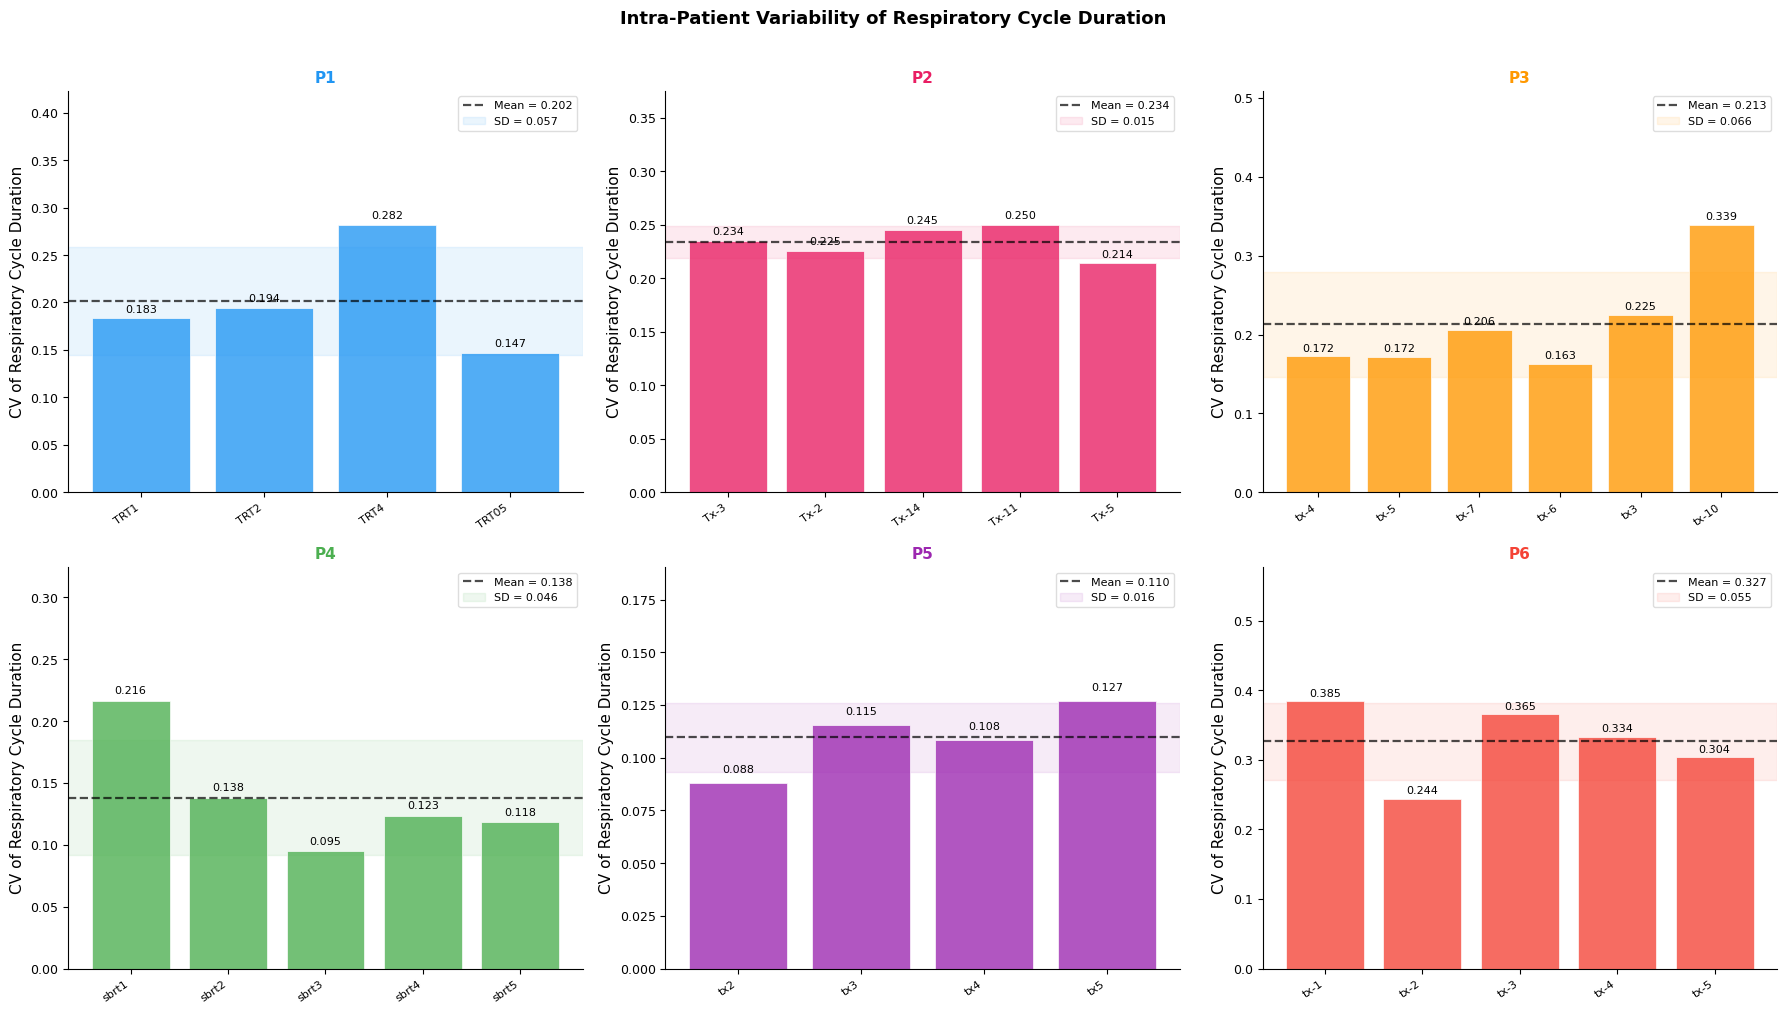


Generating Figure 4 — Intra-patient tidal volume amplitude variability...
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig4_intra_cv_amplitude.png


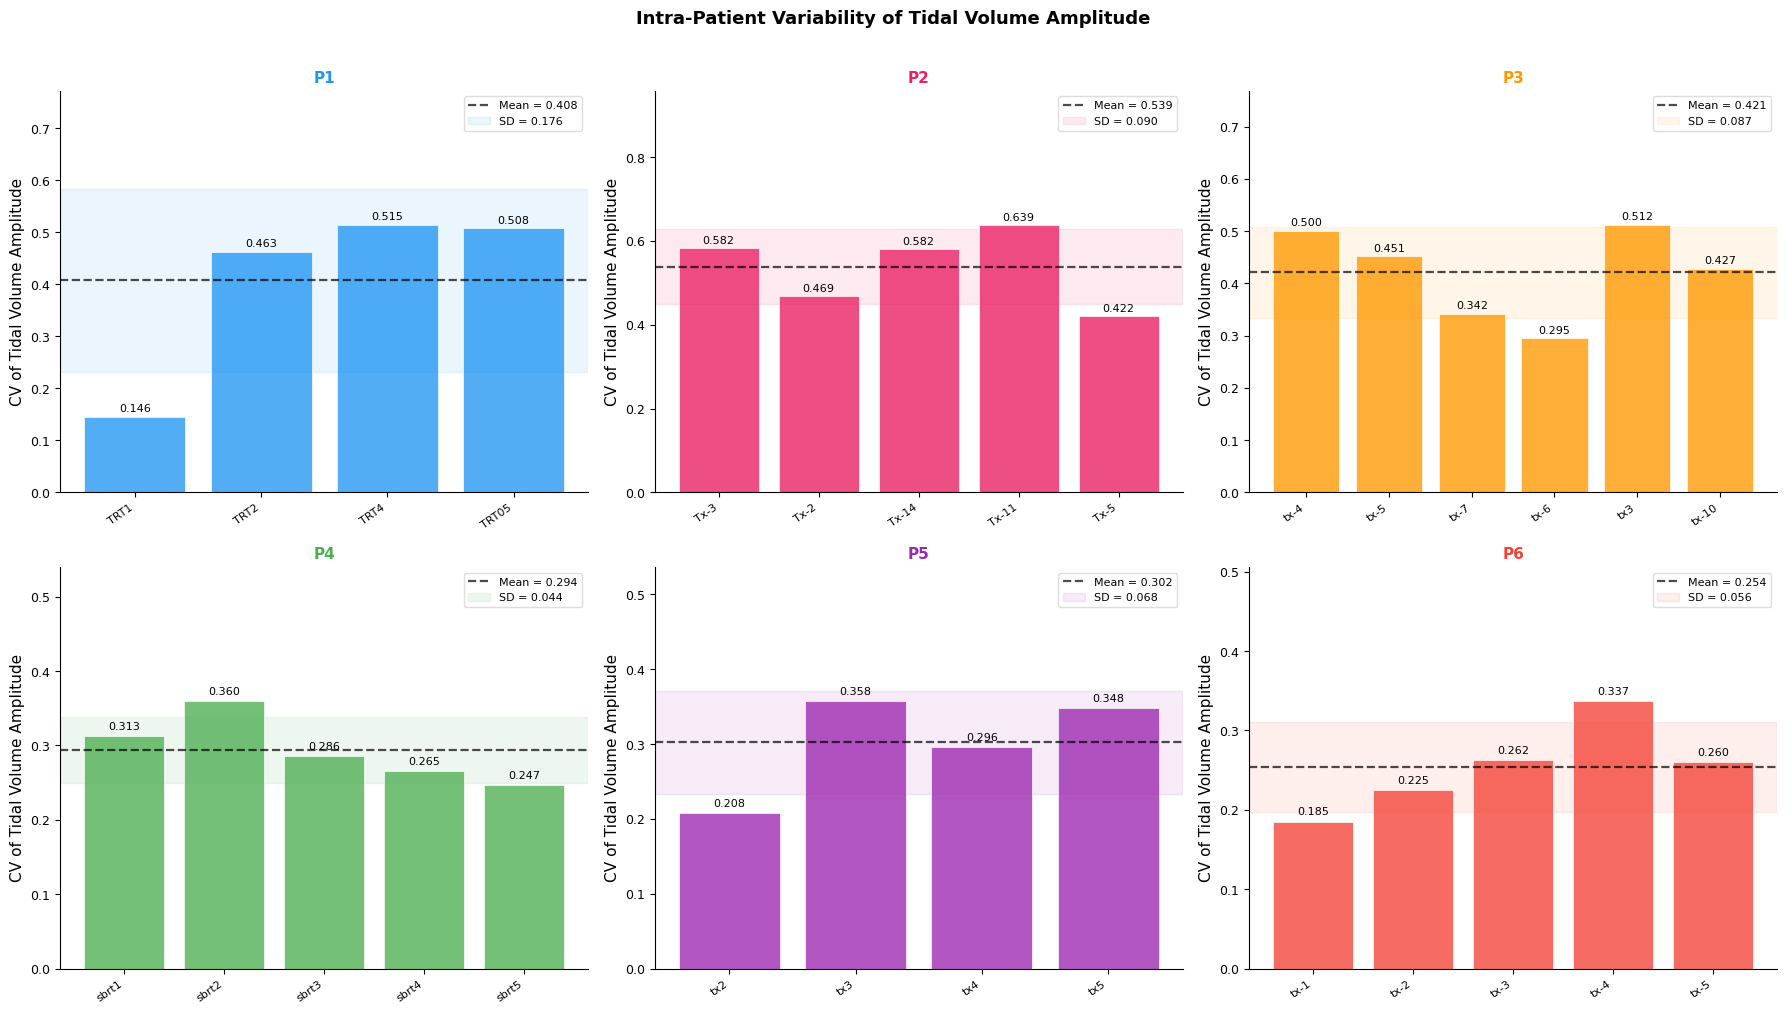


Generating Figure 5: Inter-patient CV_duration comparison
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig5_inter_cv_duration.png


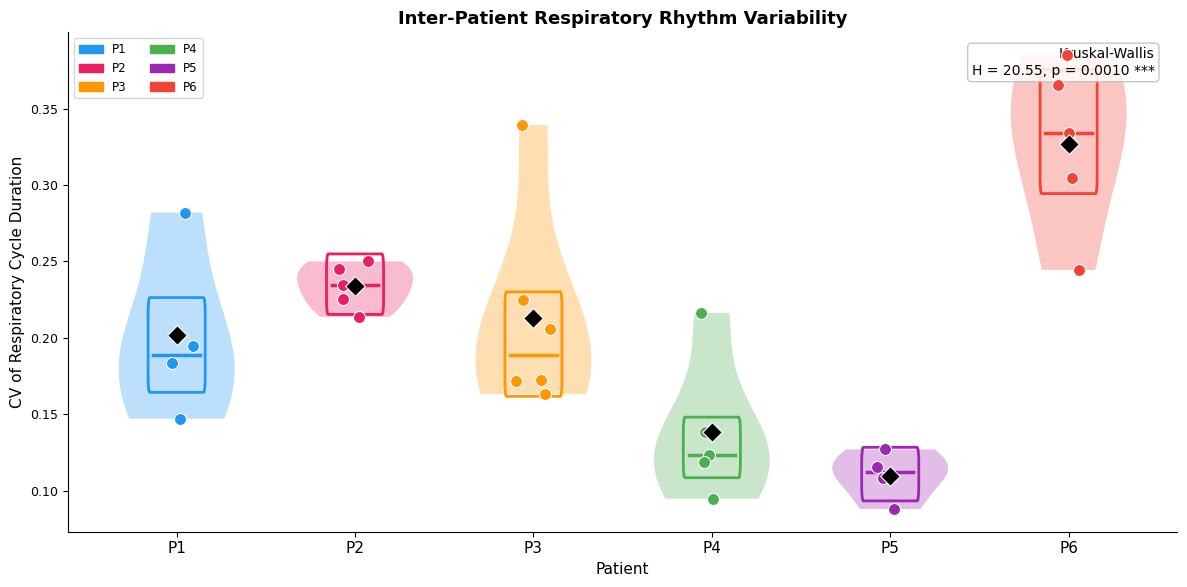


Generating Figure 6 — Inter-patient tidal volume amplitude variability...
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig6_inter_cv_amplitude.png


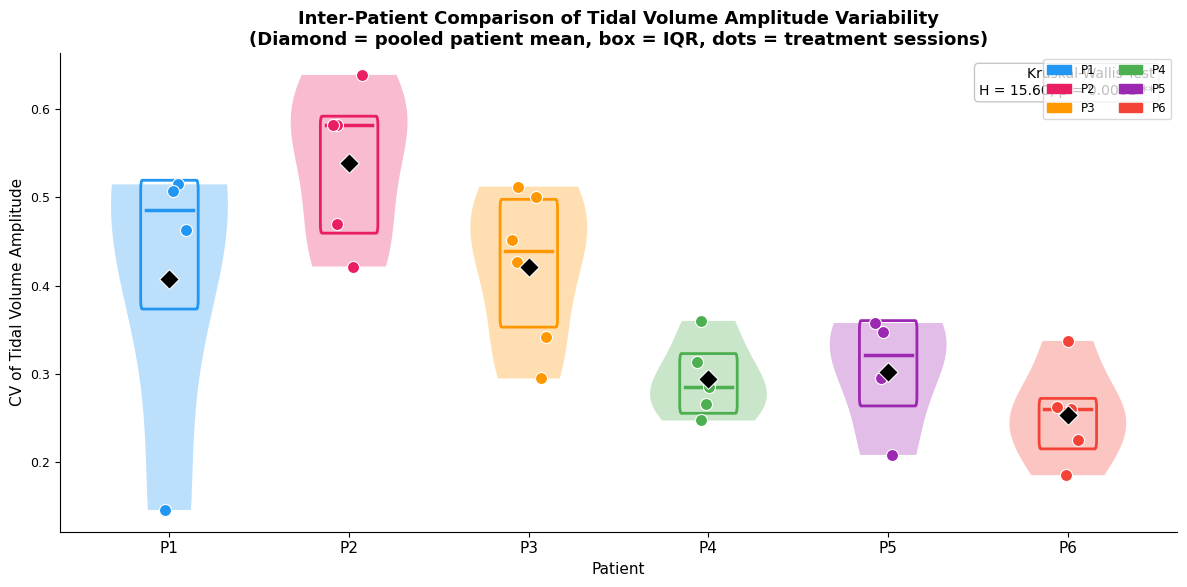


Generating Figure 7: Inter-patient respiratory variability profile
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig7_respiratory_variability_profile.png


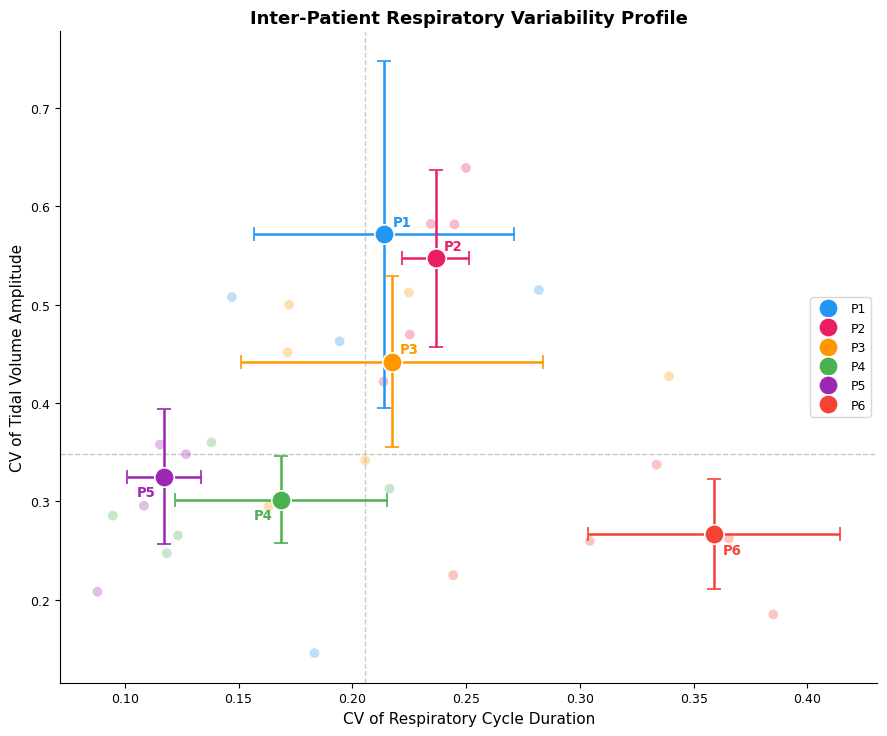


Generating Figure 8 — Poincaré respiratory variability plots...
  Saved -> C:\Users\ruthm\Abdominal Compression - Research\fig8_poincare.png


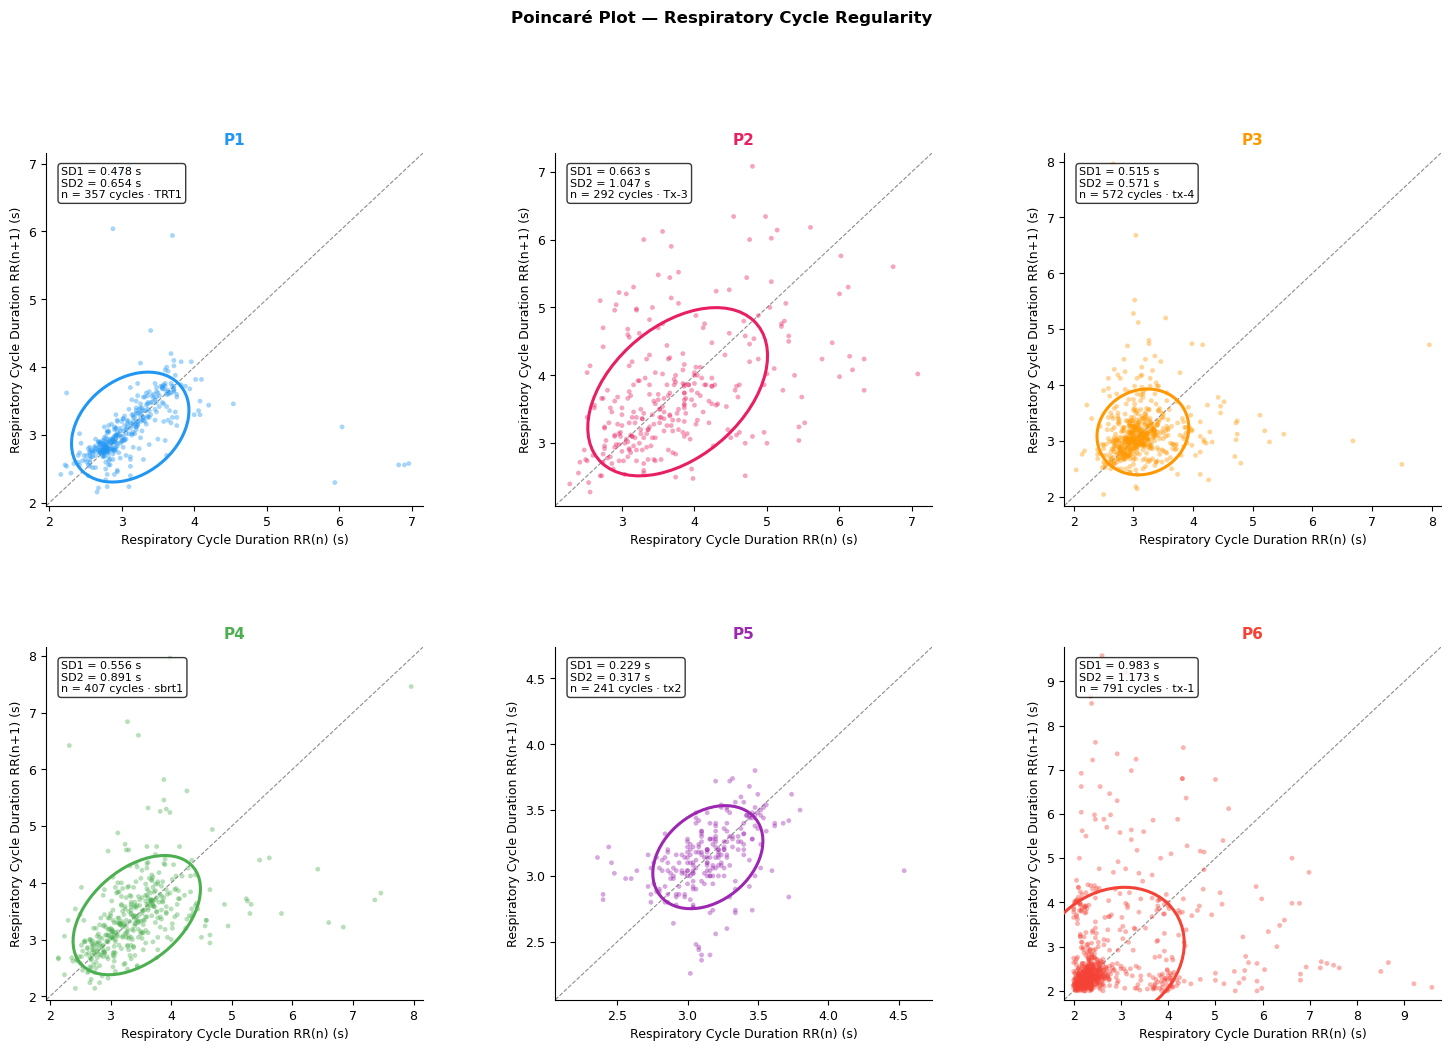


Table 1 — Descriptive Statistics per Patient
Patient                Sessions  Cycles  RR(bpm)  Dur_mean  CV_dur  Amp_mean  CV_amp
----------------------------------------------------------------------------
P1                            4    1125     18.5     3.237   0.214     0.331   0.571
P2                            5    1714     16.8     3.569   0.237     0.740   0.547
P3                            6    2271     19.3     3.114   0.217     0.430   0.442
P4                            5    2501     20.4     2.942   0.169     0.408   0.302
P5                            4    1185     20.2     2.963   0.117     0.750   0.325
P6                            5    2855     19.9     3.011   0.359     0.392   0.267

Table 2 — Intra-Patient Consistency
Patient                 CVd_spread   CoV_CVd  CVa_spread   CoV_CVa   Stable?
----------------------------------------------------------------------------
P1                           0.057     0.284       0.176     0.432       YES
P2            

In [28]:
def run_visualizations(all_results, comparison_df=None):

    print('=' * 72)
    print('RESPIRATORY VARIABILITY — VISUALISATION AND STATISTICAL ANALYSIS')
    print('Using existing outputs from the approved analysis pipeline')
    print('=' * 72)

    if all_results is None or len(all_results) == 0:
        print('\nNo processed analysis results found.')
        print('Run the primary pipeline first:')
        print('all_results, comparison_df = run_all(BASE_PATH)')
        return

    # Figure 1 — Respiratory waveform and cycle detection
    fig1_waveform(all_results)

    # Figure 2 — Respiratory cycle duration timeseries
    fig2_duration_timeseries(all_results)

    # Figure 3 — Intra-patient CV_duration variability
    fig3_intra_cv_duration(all_results)

    # Figure 4 — Intra-patient CV_amplitude variability
    fig4_intra_cv_amplitude(all_results)

    # Figure 5 — Inter-patient CV_duration comparison
    fig5_inter_cv_duration(all_results)

    # Figure 6 — Inter-patient CV_amplitude comparison
    fig6_inter_cv_amplitude(all_results)

    # Figure 7 — Multidimensional breathing variability profile
    fig7_scatter_profile(all_results)

    # Figure 8 — Poincaré respiratory variability analysis
    fig8_poincare(all_results)

    # Statistical summary tables
    print_statistics(all_results)

    print(f'\nAnalysis complete. All outputs saved to:\n{OUTPUT_DIR}')

run_visualizations(all_results, comparison_df)

# Results Summary

Respiratory variability analysis was successfully performed across all treatment-session recordings included in the study cohort.

The implemented preprocessing and respiratory cycle detection framework enabled extraction of physiologically valid respiratory cycles from ABC spirometry waveforms across all analysed patients.

Both intra-patient and inter-patient respiratory variability characteristics were evaluated using respiratory cycle duration and tidal volume amplitude variability metrics.

Key observations from the analysis include:

- measurable intra-patient respiratory variability across treatment fractions,
- patient-specific differences in respiratory rhythm stability,
- statistically significant inter-patient differences in respiratory variability metrics,
- and heterogeneous respiratory amplitude behaviour across the cohort.

The generated visualisations and statistical analyses collectively demonstrate that respiratory dynamics under ABC-guided radiotherapy remain patient dependent despite respiratory control conditions.

# Physiological Interpretation

The observed variability patterns suggest that respiratory regularity under ABC-guided radiotherapy is influenced by individual patient-specific breathing behaviour.

Patients exhibiting lower respiratory cycle variability demonstrated more stable breathing rhythms across treatment sessions, whereas other patients showed increased temporal variability and amplitude dispersion.

The inter-patient variability identified through Kruskal-Wallis statistical analysis supports the hypothesis that respiratory behaviour cannot be assumed to be uniform across patients undergoing ABC-assisted treatment.

These findings support the physiological relevance of patient-specific respiratory assessment during radiotherapy workflow optimisation and motion-management studies.

# Study Limitations

This study represents an exploratory pilot analysis performed on a limited single-centre cohort of patients undergoing ABC-guided radiotherapy.

The primary limitation is the relatively small cohort size, which restricts statistical power and limits generalisation of the findings to broader patient populations.

In addition, the study focused specifically on respiratory variability characterisation using respiratory cycle duration and tidal volume amplitude metrics derived from ABC spirometry recordings. The analysis was therefore designed to evaluate variability behaviour rather than establish direct clinical or dosimetric outcomes.

No tumour-motion correlation or treatment-dose analysis was performed, and the findings should therefore be interpreted as physiological and computational observations within the context of respiratory variability assessment.

Despite these limitations, the study demonstrates that measurable intra-patient and inter-patient respiratory variability can be quantified reproducibly from ABC respiratory waveforms during radiotherapy treatment sessions.

Future work may extend this framework toward larger prospective cohorts, respiratory motion correlation studies, and patient-specific motion-management modelling for abdominal and thoracic radiotherapy applications.

# Conclusion

This notebook presents a complete respiratory variability analysis framework for ABC spirometry recordings acquired during radiotherapy treatment sessions.

The implemented pipeline combines respiratory waveform preprocessing, physiological cycle detection, variability quantification, statistical analysis, and multidimensional visualisation within a reproducible computational workflow.

The results demonstrate the presence of both intra-patient and inter-patient respiratory variability under ABC-guided radiotherapy conditions, highlighting the importance of patient-specific respiratory assessment in motion-management applications.

The developed framework provides a reproducible foundation for future respiratory dynamics studies and radiotherapy breathing-motion research.

---
End of notebook.
---